In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.getcwd()

'c:\\Users\\hamoud\\Desktop\\Iris_dataset'

In [3]:
data = pd.read_csv('iris_dataset.csv')
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
from sklearn.model_selection import train_test_split
X = data.drop(columns=['target'])
y = data['target']
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.25, stratify=y)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(112, 4) (38, 4) (112,) (38,)


In [5]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder(sparse_output= False, handle_unknown= 'ignore')
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [6]:
num_features = X_train.select_dtypes(include=[np.number]).columns
cat_features = X_train.select_dtypes(exclude=[np.number]).columns

num_pipeline = Pipeline([
    ('imputer', imputer),
    ('scaler', scaler)      
])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', cat_encoder)      
])
preprocessing_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

In [7]:
from sklearn.linear_model import SGDClassifier
sgd_model = SGDClassifier(
    loss='log_loss',
    max_iter=2000,
    learning_rate='optimal',
    n_iter_no_change=20,
    validation_fraction=0.2,
    early_stopping=True,
    shuffle=True,
    tol=1e-6,
    random_state=42
)

In [8]:
bgd_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('classifier', sgd_model)
])
bgd_pipeline.fit(X_train, y_train)
bgd_pipeline.score(X_test, y_test)

0.9736842105263158

In [9]:
y_pred = bgd_pipeline.predict(X_test)
y_pred

array([0, 2, 2, 2, 2, 2, 1, 0, 2, 0, 0, 1, 0, 1, 0, 2, 0, 2, 1, 2, 1, 1,
       1, 0, 0, 0, 1, 1, 2, 2, 0, 2, 1, 1, 0, 2, 1, 0])

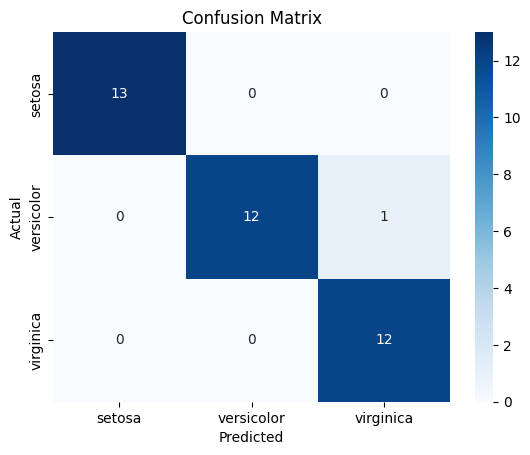

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=["setosa","versicolor","virginica"],
            yticklabels=["setosa","versicolor","virginica"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()